In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('telco_customer_churn_filtered.csv')

# Data Understanding

In [5]:
df.shape

(7043, 12)

In [6]:
df.head()

,customerID,SeniorCitizen,Partner,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,Yes,1,DSL,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,0,No,34,DSL,Yes,No,One year,Mailed check,56.95,1889.5,No
2,3668-QPYBK,0,No,2,DSL,Yes,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,0,No,45,DSL,Yes,Yes,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,0,No,2,Fiber optic,No,No,Month-to-month,Electronic check,70.70,151.65,Yes


In [7]:
df.tail()

,customerID,SeniorCitizen,Partner,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,0,Yes,24,DSL,Yes,Yes,One year,Mailed check,84.80,1990.5,No
7039,2234-XADUH,0,Yes,72,Fiber optic,No,No,One year,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,0,Yes,11,DSL,Yes,No,Month-to-month,Electronic check,29.60,346.45,No
7041,8361-LTMKD,1,Yes,4,Fiber optic,No,No,Month-to-month,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,0,No,66,Fiber optic,Yes,Yes,Two year,Bank transfer (automatic),105.65,6844.5,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   SeniorCitizen    7043 non-null   int64  
 2   Partner          7043 non-null   object 
 3   tenure           7043 non-null   int64  
 4   InternetService  7043 non-null   object 
 5   OnlineSecurity   7043 non-null   object 
 6   TechSupport      7043 non-null   object 
 7   Contract         7043 non-null   object 
 8   PaymentMethod    7043 non-null   object 
 9   MonthlyCharges   7043 non-null   float64
 10  TotalCharges     7043 non-null   object 
 11  Churn            7043 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 660.4+ KB


In [10]:
df.describe(include='object')

,customerID,Partner,InternetService,OnlineSecurity,TechSupport,Contract,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,3,3,3,3,4,6531,2
top,7590-VHVEG,No,Fiber optic,No,No,Month-to-month,Electronic check,,No
freq,1,3641,3096,3498,3473,3875,2365,11,5174


In [11]:
df.columns

Index(['customerID', 'SeniorCitizen', 'Partner', 'tenure', 'InternetService',
       'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Data Cleaning

In [12]:
df.columns = df.columns.str.strip().str.lower()

In [13]:
df.head(1)

,customerid,seniorcitizen,partner,tenure,internetservice,onlinesecurity,techsupport,contract,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,0,Yes,1,DSL,No,No,Month-to-month,Electronic check,29.85,29.85,No


In [14]:
df.isnull().sum()

customerid         0
seniorcitizen      0
partner            0
tenure             0
internetservice    0
onlinesecurity     0
techsupport        0
contract           0
paymentmethod      0
monthlycharges     0
totalcharges       0
churn              0
dtype: int64

In [15]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [16]:
print(df['totalcharges'].dtype)

float64


In [18]:
df['monthlycharges'] = df['monthlycharges'].astype(int)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.drop('customerid',axis=1)

,seniorcitizen,partner,tenure,internetservice,onlinesecurity,techsupport,contract,paymentmethod,monthlycharges,totalcharges,churn
0,0,Yes,1,DSL,No,No,Month-to-month,Electronic check,29,29.85,No
1,0,No,34,DSL,Yes,No,One year,Mailed check,56,1889.50,No
2,0,No,2,DSL,Yes,No,Month-to-month,Mailed check,53,108.15,Yes
3,0,No,45,DSL,Yes,Yes,One year,Bank transfer (automatic),42,1840.75,No
4,0,No,2,Fiber optic,No,No,Month-to-month,Electronic check,70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...
7038,0,Yes,24,DSL,Yes,Yes,One year,Mailed check,84,1990.50,No
7039,0,Yes,72,Fiber optic,No,No,One year,Credit card (automatic),103,7362.90,No
7040,0,Yes,11,DSL,Yes,No,Month-to-month,Electronic check,29,346.45,No
7041,1,Yes,4,Fiber optic,No,No,Month-to-month,Mailed check,74,306.60,Yes


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerid       7043 non-null   object 
 1   seniorcitizen    7043 non-null   int64  
 2   partner          7043 non-null   object 
 3   tenure           7043 non-null   int64  
 4   internetservice  7043 non-null   object 
 5   onlinesecurity   7043 non-null   object 
 6   techsupport      7043 non-null   object 
 7   contract         7043 non-null   object 
 8   paymentmethod    7043 non-null   object 
 9   monthlycharges   7043 non-null   int64  
 10  totalcharges     7032 non-null   float64
 11  churn            7043 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 660.4+ KB


# Data Visulaziations

# UniVariant Analyis

<Axes: xlabel='tenure', ylabel='Count'>

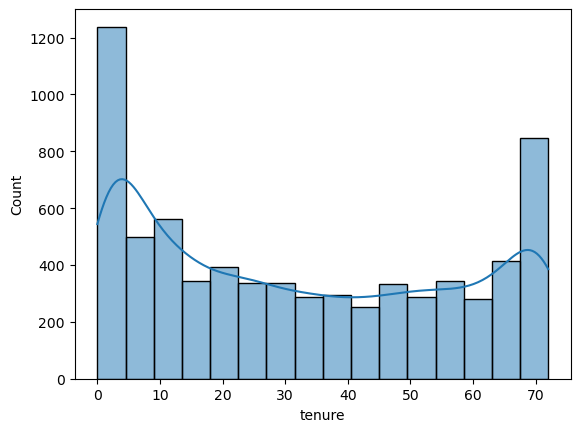

In [22]:
#Histogram
import seaborn as sns
sns.histplot(df['tenure'], kde = True)

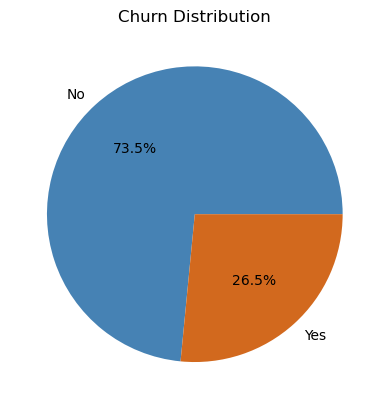

In [23]:
df['churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'chocolate'])
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()

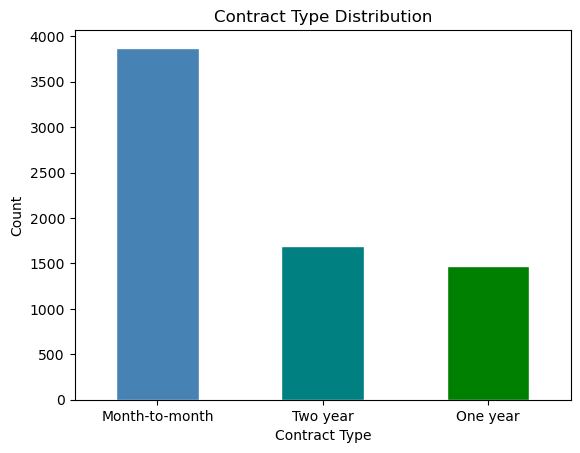

In [24]:
df['contract'].value_counts().plot(kind='bar', color=['steelblue', 'teal', 'green'], edgecolor='white')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

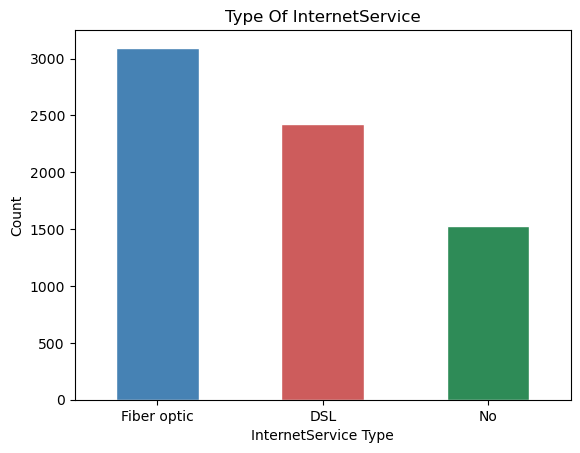

In [25]:
df['internetservice'].value_counts().plot(kind='bar', color=['steelblue', 'indianred', 'seagreen'], edgecolor='white')
plt.title('Type Of InternetService')
plt.xlabel('InternetService Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

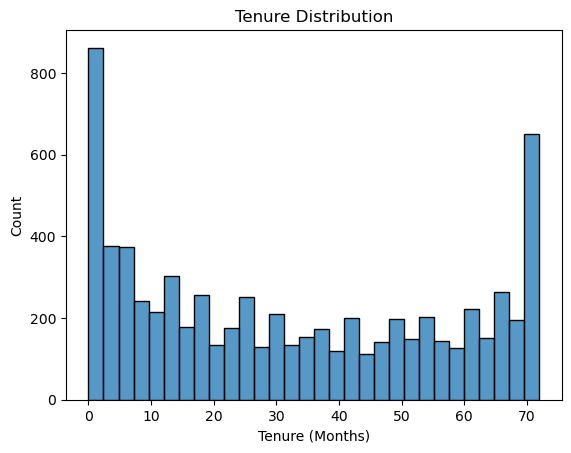

In [26]:
sns.histplot(data=df, x='tenure',  bins=30,)
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.show()

<Axes: ylabel='totalcharges'>

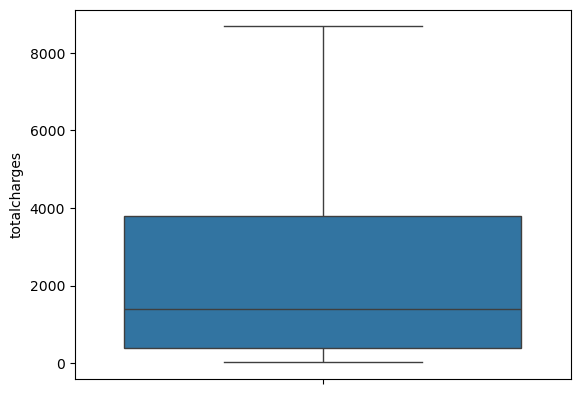

In [27]:
sns.boxplot(df['totalcharges'])

<Axes: ylabel='monthlycharges'>

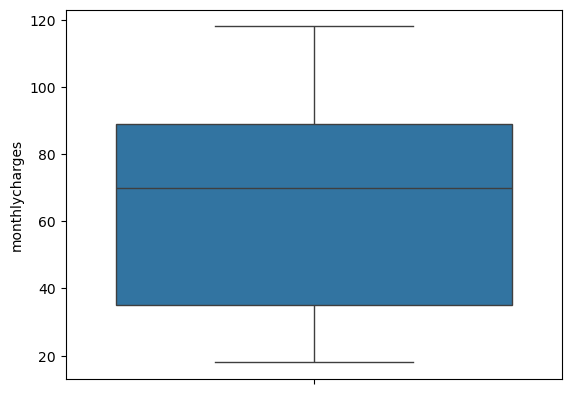

In [28]:
sns.boxplot(df['monthlycharges'])

Text(0, 0.5, 'Count')

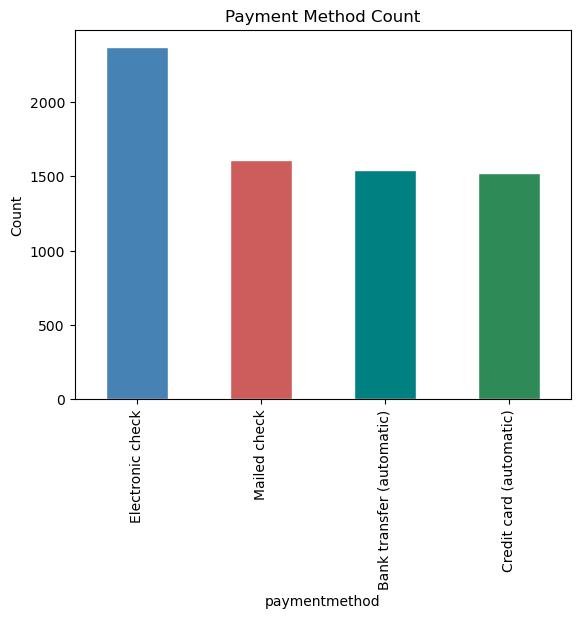

In [29]:
import matplotlib.pyplot as plt
df['paymentmethod'].value_counts().plot(kind='bar',color=['steelblue', 'indianred', 'teal','seagreen'],edgecolor='white')
plt.title('Payment Method Count')
plt.ylabel('PaymentMethod')
plt.ylabel('Count')

# Bi-Variant Analysis

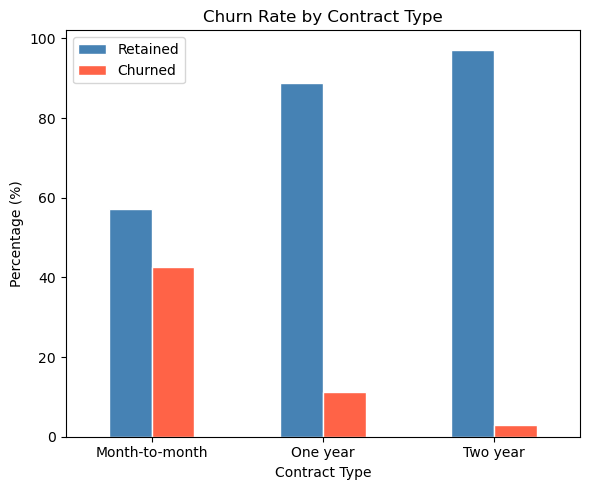

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

churn_contract = df.groupby('contract')['churn'].value_counts(normalize=True).unstack() * 100

churn_contract.plot(kind='bar', 
                    color=['steelblue', 'tomato'], 
                    edgecolor='white',
                    figsize=(6, 5))

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

<Axes: xlabel='onlinesecurity', ylabel='count'>

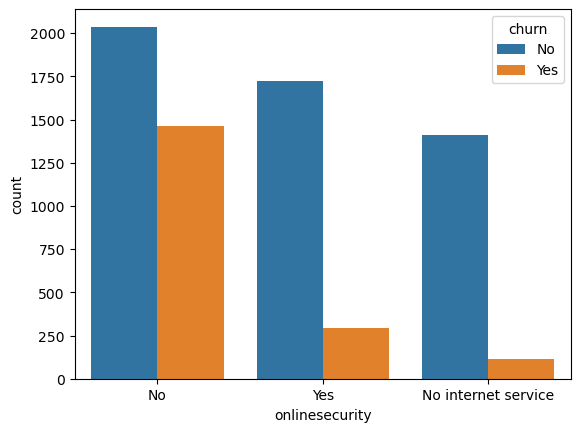

In [31]:
sns.countplot(x='onlinesecurity', hue='churn', data=df)

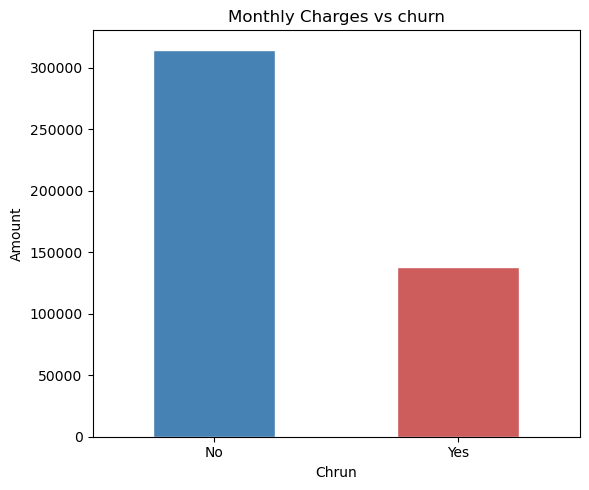

In [32]:
Monthly_Charges_vs_churn = df.groupby('churn')['monthlycharges'].sum()
Monthly_Charges_vs_churn.plot(kind='bar',color=['steelblue', 'indianred'], edgecolor='white',figsize=(6, 5))
plt.title('Monthly Charges vs churn')
plt.xlabel('Chrun')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: xlabel='techsupport', ylabel='count'>

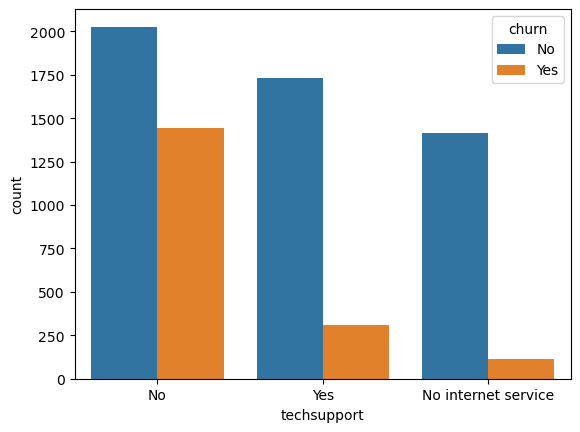

In [33]:
sns.countplot(x='techsupport', hue='churn', data=df)

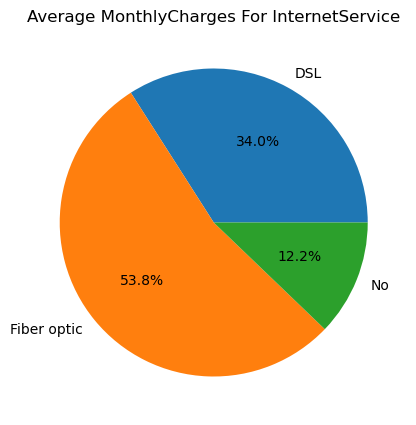

In [34]:
Avg_MonthlyCharges_For_InternetService = df.groupby('internetservice')['monthlycharges'].mean()
Avg_MonthlyCharges_For_InternetService.plot(kind='pie',autopct='%1.1f%%',color=['steelblue','indianred','teal'],figsize=(6,5))
plt.title('Average MonthlyCharges For InternetService')
plt.ylabel('')
plt.show()

# Multivariant Analysis

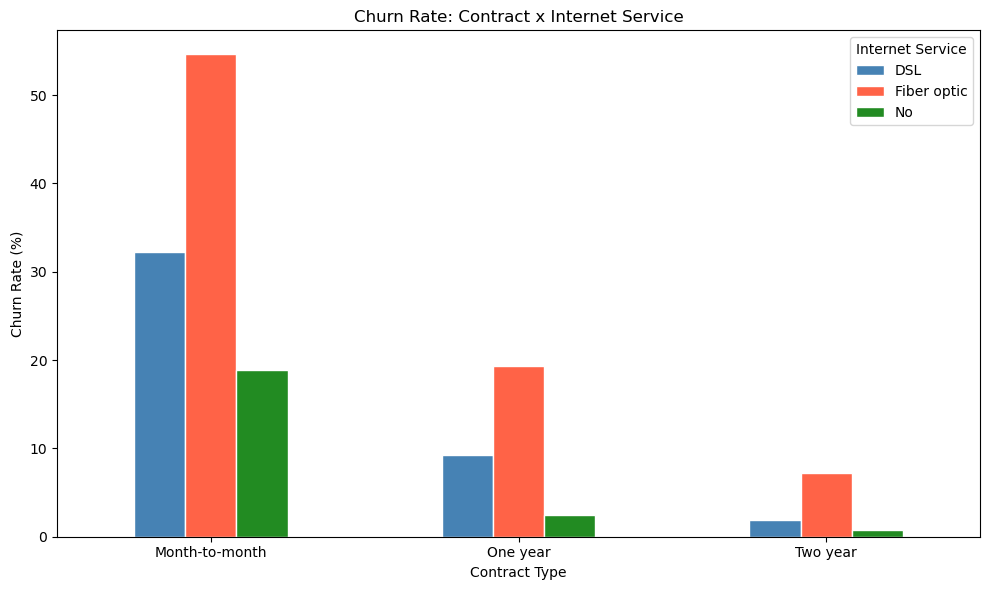

In [35]:
pivot = df.groupby(['contract', 'internetservice'])['churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).unstack()

pivot.plot(kind='bar',
           color=['steelblue', 'tomato', 'forestgreen'],
           edgecolor='white',
           figsize=(10, 6))

plt.title('Churn Rate: Contract x Internet Service')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Internet Service')
plt.tight_layout()
plt.show()

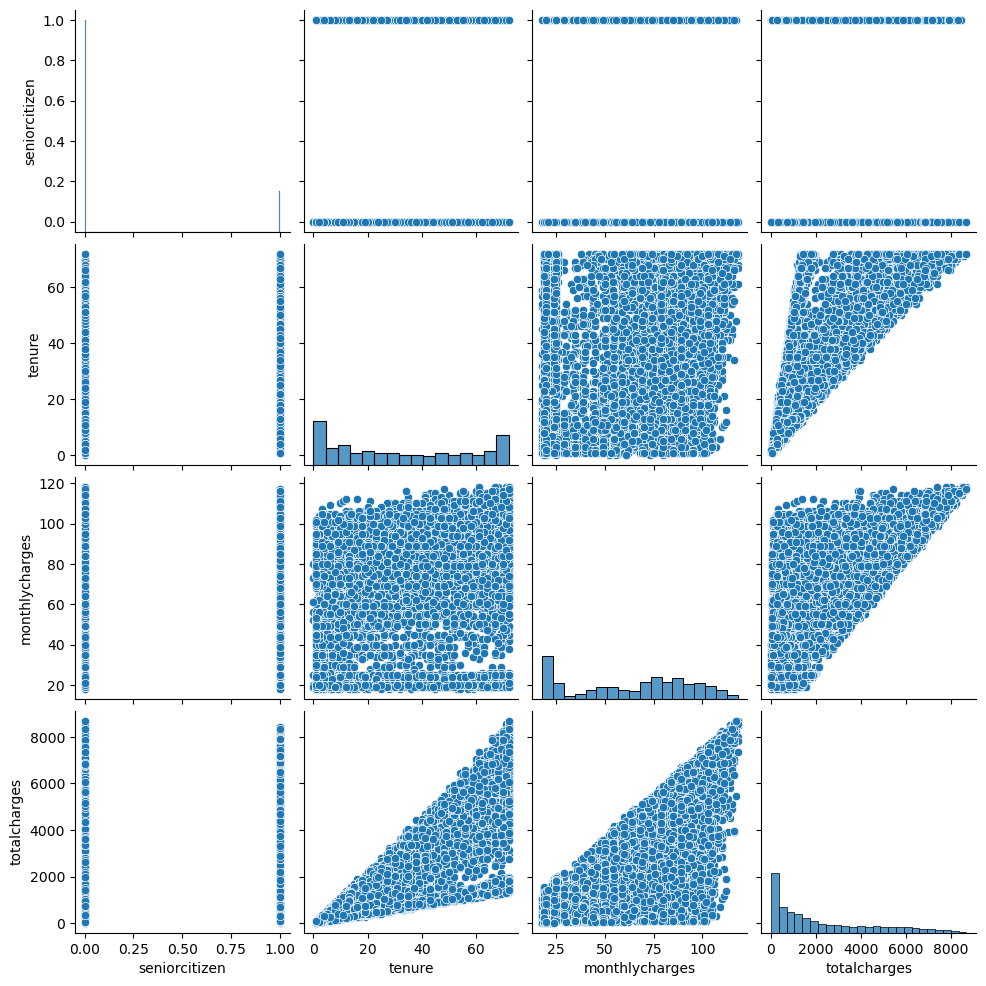

In [36]:
sns.pairplot(df)

<Axes: >

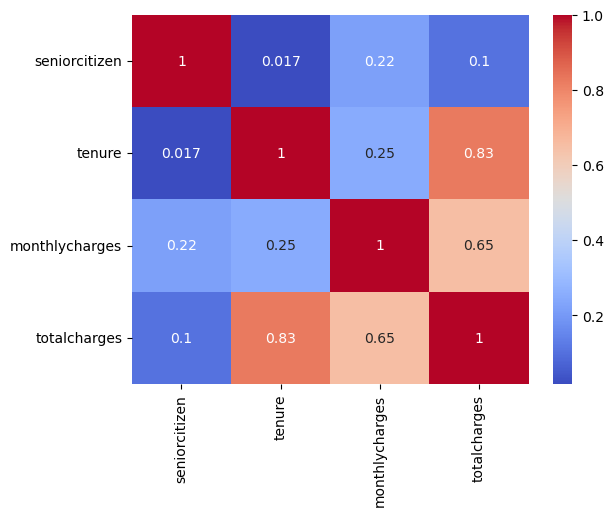

In [37]:
sns.heatmap(df.select_dtypes(include = ["int","float"]).corr(),annot = True, cmap = "coolwarm")

<Axes: xlabel='tenure', ylabel='totalcharges'>

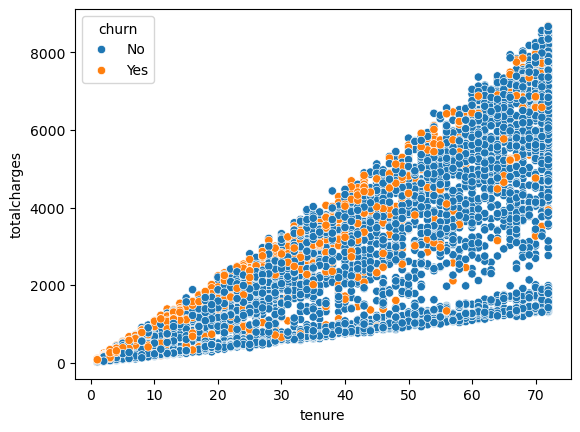

In [38]:
sns.scatterplot(y="totalcharges",x="tenure",hue='churn',data = df)

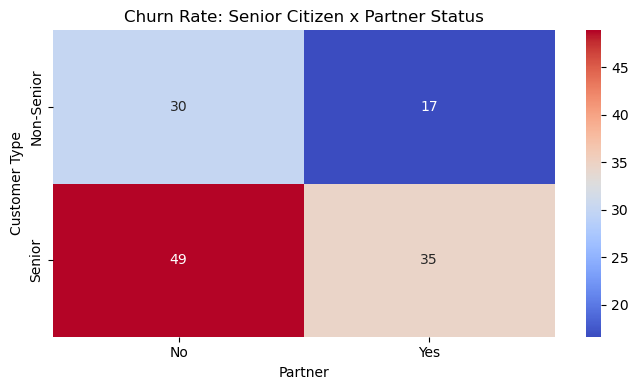

In [40]:
pivot = df.groupby(['seniorcitizen', 'partner'])['churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).unstack()

pivot.index = ['Non-Senior', 'Senior']

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True,cmap = "coolwarm")
plt.title('Churn Rate: Senior Citizen x Partner Status')
plt.xlabel('Partner')
plt.ylabel('Customer Type')
plt.tight_layout()
plt.show()